In [ ]:
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import pandas as pd
import numpy as np
import torch
import os 
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm

from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers

c:\Users\mario\Desktop\Deep Learning\Progetto\multimodal-crisis-classification\deep_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
from dotenv import load_dotenv
load_dotenv()

True

In [24]:
dataset_dir = os.getenv("DATASET_DIR")
datasplit_dir = os.getenv("DATASPLITS_DIR")

train_path = os.path.join(datasplit_dir, "mm_train.tsv")
test_path = os.path.join(datasplit_dir, "mm_test.tsv")

In [25]:
df_train = pd.read_csv(train_path, sep = "\t")
df_test = pd.read_csv(test_path, sep = "\t")

print(df_test.shape)
print(df_test.columns)


(2495, 4)
Index(['cleaned_tweet_text', 'image_path', 'mm_info', 'mm_human'], dtype='object')


In [26]:
# Ricostruisco gli encoder
le_info = LabelEncoder()
le_info.fit(df_train["mm_info"])

le_human = LabelEncoder()
le_human.fit(df_train["mm_human"])

y_test_task1 = le_info.transform(df_test["mm_info"])
y_test_task2 = le_human.transform(df_test["mm_human"])

## Load Roberta model for text prediction

In [9]:
# Percorso al modello salvato
roberta_path_task1 = "model/roberta-base_Task1/"
roberta_path_task2 = "model/roberta-base_Task2"

# Carica i modelli roberta per entrambi i task
tokenizer_roberta_task1 = RobertaTokenizer.from_pretrained(roberta_path_task1)
model_roberta_task1 = RobertaForSequenceClassification.from_pretrained(roberta_path_task1)

tokenizer_roberta_task2 = RobertaTokenizer.from_pretrained(roberta_path_task2)
model_roberta_task2 = RobertaForSequenceClassification.from_pretrained(roberta_path_task2)



## Load EfficientNetb0 for image prediction

In [10]:
def build_full_model(image_size, num_human_classes, dropout_rate=0.6, classifier_units=128):
    inputs = keras.Input(shape=(*image_size, 3))

    # Data augmentation (solo se vuoi usarla anche in inferenza, altrimenti rimuovi)
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ])

    x = data_augmentation(inputs)

    # Base model
    base_model = EfficientNetB0(input_shape=(*image_size, 3), include_top=False, weights=None)
    x = base_model(x)

    # Classifier
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(classifier_units)(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(dropout_rate)(x)

    # Two output heads
    info_out = layers.Dense(1, activation="sigmoid", name="info")(x)
    human_out = layers.Dense(num_human_classes, activation="softmax", name="human")(x)

    return keras.Model(inputs=inputs, outputs=[info_out, human_out])

# Parametri usati in fase di training
image_size = (224, 224)
num_human_classes = df_test["mm_human"].nunique()

# Ricostruisci il modello
model_effnet = build_full_model(image_size=image_size, num_human_classes=num_human_classes)

# Carica i pesi
model_effnet.load_weights("EfficientNetB0_fine_tuned.keras")
model_effnet.trainable = False  #modalità inferenza


## Inference Roberta

In [11]:
def predict_roberta(model, tokenizer, texts, task_type="binary", batch_size=32):
    """
    Esegue inferenza batch su un modello RoBERTa con barra di progresso.

    Args:
        model: HuggingFace RobertaForSequenceClassification
        tokenizer: tokenizer HuggingFace
        texts: lista di testi
        task_type: "binary" o "multiclass"
        device: "cpu" o "cuda"
        batch_size: dimensione dei batch per inferenza

    Returns:
        pred_probs: probabilità (sigmoid o softmax)
        pred_labels: classi predette
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    model.eval()

    all_probs = []
    all_labels = []

    for i in tqdm(range(0, len(texts), batch_size), desc=f"Inferenza RoBERTa ({task_type})"):
        batch_texts = texts[i:i + batch_size]

        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            logits = model(**inputs).logits

            if task_type == "binary":
                probs = torch.sigmoid(logits).squeeze().cpu().numpy()
                labels = (probs > 0.5).astype(int)

            elif task_type == "multiclass":
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                labels = np.argmax(probs, axis=1)

            else:
                raise ValueError("task_type deve essere 'binary' o 'multiclass'")

        all_probs.append(probs)
        all_labels.append(labels)

    # Unisci tutto
    pred_probs = np.concatenate(all_probs)
    pred_labels = np.concatenate(all_labels)

    return pred_probs, pred_labels

In [40]:
# Prepara i testi
texts = df_test["cleaned_tweet_text"].tolist()

probs_text_task1, labels_text_task1 = predict_roberta(
    model=model_roberta_task1,
    tokenizer=tokenizer_roberta_task1,
    texts=texts,
    task_type="binary",
    batch_size=32
)

# Task 2
y_pred_text_task2_probs, y_pred_text_task2_cls = predict_roberta(
    model=model_roberta_task2,
    tokenizer=tokenizer_roberta_task2,
    texts=texts,
    task_type="multiclass",
    batch_size=32
)


Inferenza RoBERTa (multiclass): 100%|██████████| 78/78 [00:06<00:00, 12.53it/s]


In [41]:
print("probs_text_task1 shape:", np.array(probs_text_task1).shape)

print("\nPredizione sul primo task")
print(probs_text_task1[0])
print(labels_text_task1[0])

print("\n Predizione sul secondo task")
print(y_pred_text_task2_probs[0])
print(y_pred_text_task2_cls[0])

probs_text_task1 shape: (2495, 2)

Predizione sul primo task
[0.93306124 0.05165443]
[1 0]

 Predizione sul secondo task
[0.02147535 0.6310498  0.00728915 0.3393477  0.00083801]
1


In [42]:
probs_text_task1 = probs_text_task1[:, 1]  # usa solo la probabilità di classe 1
print("probs_text_task1 shape:", np.array(probs_text_task1).shape)

probs_text_task1 shape: (2495,)


## Inference EfficientNetB0

In [20]:
def predict_effnet(model, df, image_column="image_path", image_size=(224, 224), batch_size=32):
    """
    Esegue inferenza batch su un modello EfficientNet multitask.

    Args:
        model: modello Keras
        df: DataFrame con colonna path immagini
        image_column: nome della colonna dei path
        image_size: dimensione delle immagini
        batch_size: dimensione del batch

    Returns:
        probs_task1, labels_task1, probs_task2, labels_task2
    """
    paths = df[image_column].tolist()
    probs_task1 = []
    probs_task2 = []

    for i in tqdm(range(0, len(paths), batch_size), desc="Inferenza EfficientNet"):
        batch_paths = paths[i:i+batch_size]
        batch_images = []

        for path in batch_paths:
            try:
                img = image.load_img(path, target_size=image_size)
                img_array = image.img_to_array(img)
                img_array = preprocess_input(img_array)
                batch_images.append(img_array)
            except Exception as e:
                print(f"Errore immagine {path}: {e}")
                batch_images.append(np.zeros((*image_size, 3)))

        batch_images = np.array(batch_images)
        p_task1, p_task2 = model.predict(batch_images, verbose=0)
        probs_task1.extend(p_task1.squeeze())
        probs_task2.extend(p_task2)

    # Task 1: binario
    labels_task1 = (np.array(probs_task1) > 0.5).astype(int)

    # Task 2: multiclass
    labels_task2 = np.argmax(np.array(probs_task2), axis=1)

    return np.array(probs_task1), labels_task1, np.array(probs_task2), labels_task2


In [21]:
probs_img_task1, labels_img_task1, probs_img_task2, labels_img_task2 = predict_effnet(
    model=model_effnet,
    df=df_test,
    image_column="image_path"
)

Inferenza EfficientNet: 100%|██████████| 78/78 [01:01<00:00,  1.28it/s]


In [ ]:
print("probs_img_task1 shape :", np.array(probs_img_task1).shape)

print("\nPredizione sul primo task")
print(probs_img_task1[0])
print(labels_img_task1[0])

print("\n Predizione sul secondo task")
print(probs_img_task2[0])
print(labels_img_task2[0])

# Mapping delle classi nel LabelEncoder
print("Label mapping:", dict(zip(le_info.classes_, le_info.transform(le_info.classes_))))

Predizione sul primo task
0.27946395
0

 Predizione sul secondo task
[9.134823e-04 3.594342e-05 1.103789e-01 2.817445e-03 8.858543e-01]
4
Label mapping: {'informative': 0, 'not_informative': 1}


## Late Fusion

In [50]:
def late_fusion_predict(probs_text, probs_img, true_labels, task_type="binary", weight_text=0.5, label_encoder=None, task_name=""):
    """
    Esegue late fusion tra predizioni testuali e visive e valuta le metriche.

    Args:
        probs_text: predizioni probabilistiche dal modello testuale
        probs_img: predizioni probabilistiche dal modello immagine
        true_labels: array con le label vere
        task_type: "binary" o "multiclass"
        weight_text: peso del modello testuale (0.0–1.0)

    Returns:
        pred_labels: classi predette finali
    """
    alpha = weight_text
    fused_probs = alpha * probs_text + (1 - alpha) * probs_img

    if task_type == "binary":
        pred_labels = (fused_probs > 0.5).astype(int)
        precision = precision_score(true_labels, pred_labels)
        recall = recall_score(true_labels, pred_labels)
        f1 = f1_score(true_labels, pred_labels)
        acc = accuracy_score(true_labels, pred_labels)

    elif task_type == "multiclass":
        pred_labels = np.argmax(fused_probs, axis=1)
        precision = precision_score(true_labels, pred_labels, average="macro")
        recall = recall_score(true_labels, pred_labels, average="macro")
        f1 = f1_score(true_labels, pred_labels, average="macro")
        acc = accuracy_score(true_labels, pred_labels)

    else:
        raise ValueError("task_type deve essere 'binary' o 'multiclass'")

    print(f"\n📊 Late Fusion - {task_type.upper()}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    # 📉 Confusion Matrix
    cm = confusion_matrix(true_labels, pred_labels)
    labels = label_encoder.classes_ if label_encoder else None
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {task_name}")
    if task_type == "multiclass":
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return pred_labels



📊 Late Fusion - BINARY
Accuracy : 0.8253
Precision: 0.6159
Recall   : 0.8554
F1-score : 0.7161


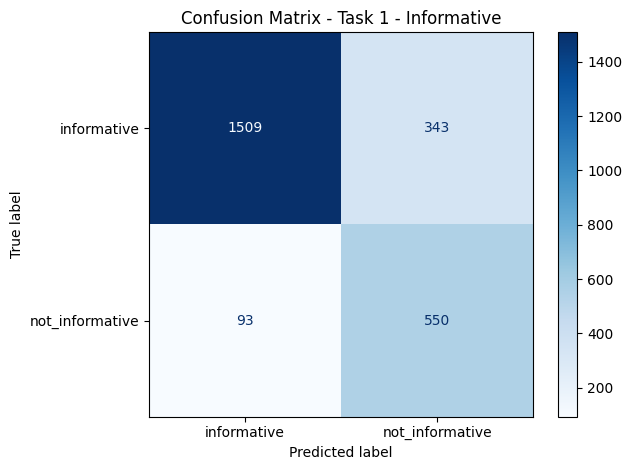


📊 Late Fusion - MULTICLASS
Accuracy : 0.6701
Precision: 0.7472
Recall   : 0.6167
F1-score : 0.6451


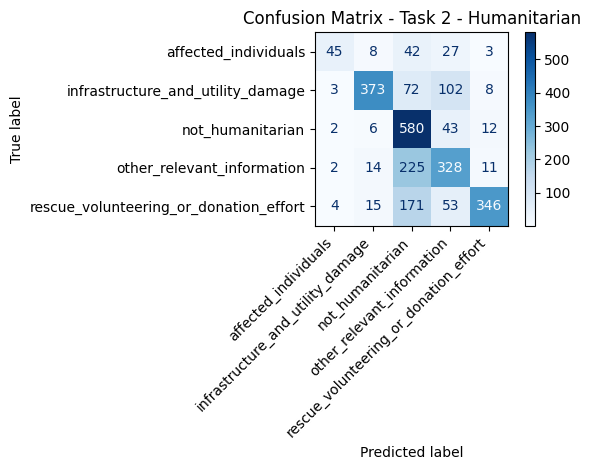

In [51]:
# Task 1 - binario
pred_task1 = late_fusion_predict(
    probs_text=probs_text_task1,
    probs_img=probs_img_task1,
    true_labels=y_test_task1,
    task_type="binary",
    weight_text=0.5,
    label_encoder=le_info,
    task_name="Task 1 - Informative"
)

# Task 2 - multiclass
pred_task2 = late_fusion_predict(
    probs_text=y_pred_text_task2_probs,
    probs_img=probs_img_task2,
    true_labels=y_test_task2,
    task_type="multiclass",
    weight_text=0.5,
    label_encoder=le_human,
    task_name="Task 2 - Humanitarian"
)
